## 2. Machine Learning for Regression


In [8]:
%pip install pandas numpy scikit-learn seaborn
import pandas as pd
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 21.7 MB/s  0:00:00 eta 0:00:0136m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 37.7 MB/s  0:00:00s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 40.9 MB/s  0:00:00 259.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 38.6 MB/s  0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 35.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 42.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 44.5 MB/s  0:00:00s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [seaborn]5;237m━━ 15/16 [seaborn]earn]
Note: you may need to restart the kernel to use updated packages.


## 2.2 Data preparation

In [47]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [48]:
!wget $data 

--2026-10-06 03:58:54--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.1’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.02s   

2026-10-06 03:58:54 (27.9 MB/s) - ‘car_fuel_efficiency_2026.csv.1’ saved [635180/635180]



In [49]:
df = pd.read_csv(data)

In [50]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [53]:
#df['make'].str.lower().str.replace(' ', '_')

In [55]:
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [56]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['origin', 'fuel_type', 'drivetrain']

In [57]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [58]:
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

## 2.3 Exploratory data analysis

In [59]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

model_year
[2006 2008 1996 1989 1994]
50

origin
<StringArray>
['europe', 'asia', 'usa']
Length: 3, dtype: str
3

fuel_type
<StringArray>
['gasoline', 'diesel', 'hybrid']
Length: 3, dtype: str
3

drivetrain
<StringArray>
['front-wheel_drive', 'rear-wheel_drive', 'all-wheel_drive']
Length: 3, dtype: str
3

num_doors
[4 5 3 2]
4

engine_displacement
[2180 2390 2320 2130 2580]
127

num_cylinders
[6 7 5 8 4]
5

horsepower
[243. 272. 267. 258. 304.]
153

vehicle_weight
[3870 4210 4240 4490 4510]
176

acceleration
[ nan 17.3 18.7 17.5 18.8]
93

fuel_efficiency_mpg
[31.9 31.3 27.5 28.5 31. ]
188



In [60]:
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,europe,gasoline,front-wheel_drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,europe,diesel,front-wheel_drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,asia,gasoline,front-wheel_drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,europe,gasoline,front-wheel_drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,usa,diesel,front-wheel_drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,usa,gasoline,all-wheel_drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,asia,gasoline,all-wheel_drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,usa,gasoline,all-wheel_drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,usa,hybrid,rear-wheel_drive,5,2180,6,270.0,4450,20.9,32.2


Distribution of price

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

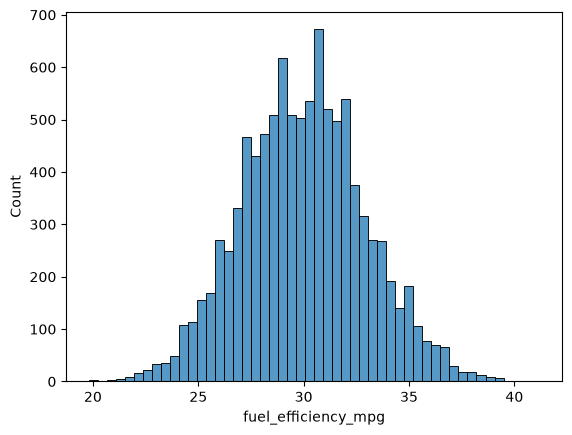

In [63]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

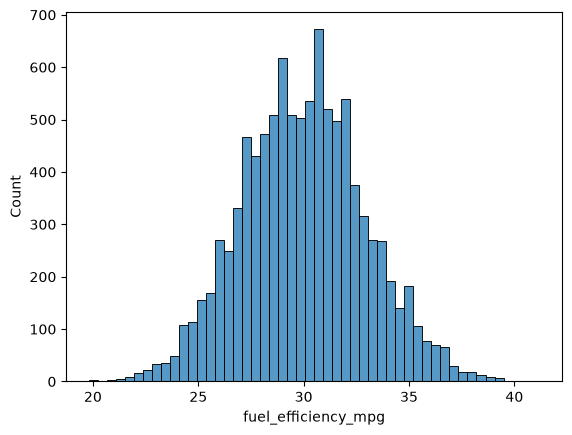

In [64]:
sns.histplot(df.fuel_efficiency_mpg[df.fuel_efficiency_mpg < 100000], bins=50)

In [65]:
np.log1p([0, 1, 10, 1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [66]:
np.log([0 + 1, 1+ 1, 10 + 1, 1000 + 1, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51292546])

In [68]:
price_logs = np.log1p(df.fuel_efficiency_mpg)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

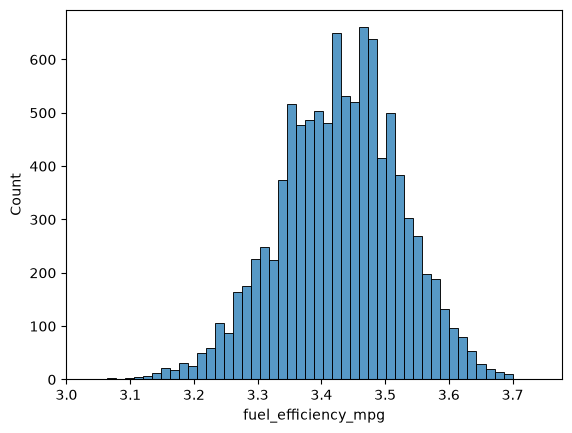

In [69]:

sns.histplot(price_logs, bins=50)

Missing values

In [70]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [71]:
df.isna().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [75]:
df['horsepower'].median()

np.float64(254.0)

## 2.4 Setting up the validation framework

In [76]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

Let's draw it

## 2.5 Linear regression

draw

In [77]:
df_train.iloc[10]

model_year                         2002
origin                              usa
fuel_type                      gasoline
drivetrain             rear-wheel_drive
num_doors                             4
engine_displacement                2440
num_cylinders                         6
horsepower                        288.0
vehicle_weight                     4440
acceleration                       16.2
fuel_efficiency_mpg                25.7
Name: 2750, dtype: object

In [78]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [79]:
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [80]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [81]:
linear_regression(xi)

12.312

In [82]:
np.expm1(12.312)

np.float64(222347.2221101062)

In [83]:
np.log1p(222347.2221101062)

np.float64(12.312)

## 2.6 Linear regression vector form

In [84]:
def dot(xi, w):
    n = len(xi)
    
    res = 0.0
    
    for j in range(n):
        res = res + xi[j] * w[j]
    
    return res

In [85]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [86]:
w_new = [w0] + w

In [87]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [88]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [89]:
linear_regression(xi)

12.312

In [90]:
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [91]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [92]:
def linear_regression(X):
    return X.dot(w_new)

In [93]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

In [109]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [110]:
# Variable objetivo (sin logaritmo)
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values

# Columna de la Q1 y variables numéricas
col = 'horsepower'
features = df.select_dtypes(include='number').columns.drop('fuel_efficiency_mpg').tolist()

def prepare_X(df_, fill_value):
    df_ = df_[features].copy()
    df_[col] = df_[col].fillna(fill_value)
    return df_.fillna(0).values   # otros nulos (p. ej. acceleration) a 0, para que no falle

# Opción 1: rellenar con 0
w0, w = train_linear_regression(prepare_X(df_train, 0), y_train)
score_0 = rmse(y_val, w0 + prepare_X(df_val, 0).dot(w))

# Opción 2: rellenar con la media del TRAIN
mean_train = df_train[col].mean()
w0, w = train_linear_regression(prepare_X(df_train, mean_train), y_train)
score_mean = rmse(y_val, w0 + prepare_X(df_val, mean_train).dot(w))

print("Con 0:", round(score_0, 3))
print("Con media:", round(score_mean, 3))

Con 0: 2.205
Con media: 2.201


In [111]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

# NAs a 0 en todas las columnas, como pide el enunciado
X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)

resultados = {}
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    resultados[r] = round(rmse(y_val, y_pred), 4)
    print(r, resultados[r])

# Mejor r: menor RMSE redondeado y, en caso de empate, el menor r
mejor_r = min(resultados, key=lambda r: (resultados[r], r))
print("Mejor r:", mejor_r)

0 2.2047
0.01 2.2052
0.1 2.2233
1 2.3469
5 2.4062
10 2.4162
100 2.4257
Mejor r: 0


In [112]:
scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)

    df_train_s = df.iloc[idx[:n_train]]
    df_val_s = df.iloc[idx[n_train:n_train + n_val]]

    y_train_s = df_train_s['fuel_efficiency_mpg'].values
    y_val_s = df_val_s['fuel_efficiency_mpg'].values

    X_train_s = prepare_X(df_train_s, 0)
    X_val_s = prepare_X(df_val_s, 0)

    w0, w = train_linear_regression(X_train_s, y_train_s)
    y_pred = w0 + X_val_s.dot(w)

    score = rmse(y_val_s, y_pred)
    scores.append(score)
    print(seed, score)

std = np.std(scores)
print("std:", round(std, 3))

0 2.2412812778301263
1 2.201882999653478
2 2.1589497421034385
3 2.2003788577324848
4 2.197077535231482
5 2.2456610733506355
6 2.2696410836928034
7 2.183920730360725
8 2.214278945075966
9 2.205285971730841
std: 0.031


In [114]:
# Split 60/20/20 con seed 9
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

df_train_9 = df.iloc[idx[:n_train]]
df_val_9 = df.iloc[idx[n_train:n_train + n_val]]
df_test_9 = df.iloc[idx[n_train + n_val:]]

# Combinar train y validation
df_full_train = pd.concat([df_train_9, df_val_9])
y_full_train = df_full_train['fuel_efficiency_mpg'].values
y_test = df_test_9['fuel_efficiency_mpg'].values

# NAs a 0 y entrenamiento con r=0.001
X_full_train = prepare_X(df_full_train, 0)
X_test = prepare_X(df_test_9, 0)

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
y_pred = w0 + X_test.dot(w)

print("RMSE test:", rmse(y_test, y_pred))

RMSE test: 2.234585068352127


## 2.7 Training a linear regression model

In [94]:
def train_linear_regression(X, y):
    pass

In [95]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [96]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [97]:
X = np.column_stack([ones, X])

In [98]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [99]:
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)

In [100]:
w0 = w_full[0]
w = w_full[1:]

In [101]:
w0, w

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [102]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [103]:
train_linear_regression(X, y)

LinAlgError: Singular matrix

## 2.8 Car price baseline model

In [104]:
df_train.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [105]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']

X_train = df_train[base].fillna(0).values

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)

KeyError: "None of [Index(['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg',\n       'popularity'],\n      dtype='str')] are in the [columns]"

In [106]:
w0

np.float64(25844.754055766753)

In [107]:
w

array([ -16.08906468, -199.47254894,   -1.22802883])

In [5]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)


NameError: name 'sns' is not defined

## 2.9 RMSE

In [ ]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [ ]:
rmse(y_train, y_pred)

## 2.10 Validating the model

In [ ]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [ ]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

## 2.11 Simple feature engineering

In [ ]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [ ]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

In [ ]:
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50)
plt.legend()

## 2.12 Categorical variables

In [ ]:
categorical_columns = [
    'make', 'model', 'engine_fuel_type', 'driven_wheels', 'market_category',
    'vehicle_size', 'vehicle_style']

categorical = {}

for c in categorical_columns:
    categorical[c] = list(df_train[c].value_counts().head().index)

In [ ]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']

    for v in [2, 3, 4]:
        df['num_doors_%d' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%d' % v)

    for name, values in categorical.items():
        for value in values:
            df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
            features.append('%s_%s' % (name, value))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [ ]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

In [ ]:
w0, w

## 2.13 Regularization

In [ ]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.00000001],
]

X = np.array(X)
X

In [ ]:
y= [1, 2, 3, 1, 2, 3]

In [ ]:
XTX = X.T.dot(X)
XTX

In [ ]:
XTX_inv = np.linalg.inv(XTX)

In [ ]:
XTX_inv

In [ ]:
XTX_inv.dot(X.T).dot(y)

In [ ]:
XTX = [
    [1, 2, 2],
    [2, 1, 1.0000001],
    [2, 1.0000001, 1]
]

XTX = np.array(XTX)

In [ ]:
np.linalg.inv(XTX)

In [ ]:
XTX = XTX + 0.01 * np.eye(3)

In [ ]:
np.linalg.inv(XTX)

In [ ]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [ ]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

## 2.14 Tuning the model

In [ ]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(r, w0, score)

In [ ]:
r = 0.001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score

## 2.15 Using the model

In [ ]:
df_full_train = pd.concat([df_train, df_val])

In [ ]:
df_full_train = df_full_train.reset_index(drop=True)

In [ ]:
X_full_train = prepare_X(df_full_train)

In [ ]:
X_full_train

In [ ]:
y_full_train = np.concatenate([y_train, y_val])

In [ ]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [ ]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

In [ ]:
car = df_test.iloc[20].to_dict()
car

In [ ]:
df_small = pd.DataFrame([car])
df_small

In [ ]:
X_small = prepare_X(df_small)

In [ ]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

In [ ]:
np.expm1(y_pred)

In [ ]:
np.expm1(y_test[20])

## 2.16 Next steps

* We included only 5 top features. What happens if we include 10?

Other projects

* Predict the price of a house - e.g. boston dataset
* https://archive.ics.uci.edu/ml/datasets.php?task=reg
* https://archive.ics.uci.edu/ml/datasets/Student+Performance

## 2.17 Summary

* EDA - looking at data, finding missing values
* Target variable distribution - long tail => bell shaped curve
* Validation framework: train/val/test split (helped us detect problems)
* Normal equation - not magic, but math
* Implemented it with numpy
* RMSE to validate our model
* Feature engineering: age, categorical features
* Regularization to fight numerical instability